In [ ]:
from transformers import WhisperProcessor, WhisperForConditionalGeneration
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"

model_name = "AventIQ-AI/whisper-audio-to-text"
model = WhisperForConditionalGeneration.from_pretrained(model_name).to(device)
processor = WhisperProcessor.from_pretrained(model_name)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [ ]:
from datasets import load_dataset

ds = load_dataset("lammity/my_audio_transcription_dataset")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [ ]:
!apt-get update -qq
!apt-get install -qq ffmpeg libavcodec-dev libavformat-dev libswresample-dev
!pip install torchcodec==0.9.0 evaluate jiwer torchcodec torchaudio

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)


In [ ]:
import torchaudio
import torch
import numpy as np
import evaluate

In [ ]:
wer_metric = evaluate.load("wer")
cer_metric = evaluate.load("cer")
toxicity_metric = evaluate.load("toxicity", module_type="measurement", model_name="unitary/unbiased-toxic-roberta-base")

Device set to use cpu


In [ ]:
def load_audio(file_path, target_sampling_rate=16000):
    # Load audio file
    waveform, sample_rate = torchaudio.load(file_path)

    # Convert to mono if stereo
    if waveform.shape[0] > 1:
        waveform = waveform.mean(dim=0, keepdim=True)

    # Resample if needed
    if sample_rate != target_sampling_rate:
        waveform = torchaudio.transforms.Resample(orig_freq=sample_rate, new_freq=target_sampling_rate)(waveform)

    return waveform.squeeze(0).numpy()

In [ ]:
avent_wer = 0
avent_cer = 0
avent_toxicity = []

for i, item in ds['train']: # enumerate(ds['train'].select(range(1)))
  # Get audio data directly from the dataset entry
  audio_data = item['audio']
  original_audio_array = audio_data['array']
  original_sampling_rate = audio_data['sampling_rate']

  target_sampling_rate = 16000

  # Convert original_audio_array (numpy) to a torch tensor for torchaudio operations
  # Add a channel dimension (batch_size, channels, samples) and convert to float
  waveform = torch.from_numpy(original_audio_array).unsqueeze(0).float()

  # Resample if needed
  if original_sampling_rate != target_sampling_rate:
      resampler = torchaudio.transforms.Resample(orig_freq=original_sampling_rate, new_freq=target_sampling_rate)
      waveform = resampler(waveform)

  # Convert back to numpy and remove the channel dimension
  audio_array_processed = waveform.squeeze(0).numpy()

  input_features = processor(audio_array_processed, sampling_rate=target_sampling_rate, return_tensors="pt").input_features
  input_features = input_features.to(device)

  forced_decoder_ids = processor.get_decoder_prompt_ids(language="en", task="transcribe")

  with torch.no_grad():
      predicted_ids = model.generate(input_features, forced_decoder_ids=forced_decoder_ids)

  # Decode output
  transcription = processor.batch_decode(predicted_ids, skip_special_tokens=True)[0]
  reference = item['text']

  avent_wer += wer_metric.compute(predictions=[transcription], references=[reference])
  avent_cer += cer_metric.compute(predictions=[transcription], references=[reference])
  avent_toxicity.append(transcription)

avent_wer = avent_wer / 1000
avent_cer = avent_cer / 1000
avent_toxicity = toxicity_metric.compute(predictions=avent_toxicity)['toxicity'][0]

print(f"WER Score: {avent_wer:.4f}")
print(f"CER Score: {avent_cer:.4f}")
print(f"Toxicity Score: {avent_toxicity:.4f}")

WER Score: 0.9612
CER Score: 0.8754
Toxicity Score: 0.0007


In [ ]:
# Vosk
!pip install vosk

In [ ]:
import json
import librosa
import numpy as np
from vosk import Model, KaldiRecognizer

model = Model(model_name="vosk-model-small-en-us-0.15")

vosk_wer = 0
vosk_cer = 0
vosk_toxicity = []

for i, item in enumerate(ds['train'].select(range(1))):
  audio_data = item['audio']
  original_audio_array = audio_data['array']
  original_sampling_rate = audio_data['sampling_rate']

  audio_16k = librosa.resample(original_audio_array, orig_sr=original_sampling_rate, target_sr=16000)
  audio_int16 = (audio_16k * 32767).astype(np.int16).tobytes()
  rec = KaldiRecognizer(model, 16000)
  rec.AcceptWaveform(audio_int16)
  transcription = json.loads(rec.FinalResult())['text']
  reference = item['text']

  vosk_wer += wer_metric.compute(predictions=[transcription], references=[reference])
  vosk_cer += cer_metric.compute(predictions=[transcription], references=[reference])
  vosk_toxicity.append(transcription)

vosk_wer = vosk_wer
vosk_cer = vosk_cer
vosk_toxicity = toxicity_metric.compute(predictions=vosk_toxicity)['toxicity'][0]

print(f"WER Score: {vosk_wer:.4f}")
print(f"CER Score: {vosk_cer:.4f}")
print(f"Toxicity Score: {vosk_toxicity:.4f}")

WER Score: 0.9664
CER Score: 0.5989
Toxicity Score: 0.1144


In [ ]:
# Faster whisperer
!pip install faster-whisper

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 14.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.2/41.2 MB 15.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.8/38.8 MB 16.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.4/17.4 MB 72.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 6.3 MB/s eta 0:00:00


In [ ]:
from faster_whisper import WhisperModel

model = WhisperModel("tiny", device="cpu", compute_type="int8")

whisper_wer = 0
whisper_cer = 0
whisper_toxicity = []

for i, item in enumerate(ds['train'].select(range(1))):
  audio_data = item['audio']
  original_audio_array = audio_data['array']

  reference = item['text']
  segments, info = model.transcribe(original_audio_array, beam_size=5)
  transcription = " ".join([segment.text.strip() for segment in segments])

  whisper_wer += wer_metric.compute(predictions=[transcription], references=[reference])
  whisper_cer += cer_metric.compute(predictions=[transcription], references=[reference])
  whisper_toxicity.append(transcription)

whisper_wer = whisper_wer
whisper_cer = whisper_cer
whisper_toxicity = toxicity_metric.compute(predictions=whisper_toxicity)['toxicity'][0]

print(f"WER Score: {whisper_wer:.4f}")
print(f"CER Score: {whisper_cer:.4f}")
print(f"Toxicity Score: {whisper_toxicity:.4f}")

WER Score: 1.0181
CER Score: 0.6815
Toxicity Score: 0.1187


In [ ]:
from transformers import Wav2Vec2ForCTC, Wav2Vec2Processor

# 1. Load processor and model
processor = Wav2Vec2Processor.from_pretrained("facebook/wav2vec2-base-960h")
model = Wav2Vec2ForCTC.from_pretrained("facebook/wav2vec2-base-960h")

wav_wer = 0
wav_cer = 0
wav_toxicity = []

for i, item in enumerate(ds['train'].select(range(1))):
  audio_data = item['audio']
  original_audio_array = audio_data['array']

  # FIX: Pass the raw audio array (original_audio_array) to the processor
  input_values = processor(original_audio_array, sampling_rate=16000, return_tensors="pt").input_values

  with torch.no_grad():
    logits = model(input_values).logits
  predicted_ids = torch.argmax(logits, dim=-1);

  transcription = processor.batch_decode(predicted_ids)[0]
  reference = item['text']

  wav_wer += wer_metric.compute(predictions=[transcription], references=[reference])
  wav_cer += cer_metric.compute(predictions=[transcription], references=[reference])
  wav_toxicity.append(transcription)

wav_wer = wav_wer
wav_cer = wav_cer
wav_toxicity = toxicity_metric.compute(predictions=wav_toxicity)['toxicity'][0]

print(f"WER Score: {wav_wer:.4f}")
print(f"CER Score: {wav_cer:.4f}")
print(f"Toxicity Score: {wav_toxicity:.4f}")

Some weights of Wav2Vec2ForCTC were not initialized from the model checkpoint at facebook/wav2vec2-base-960h and are newly initialized: ['wav2vec2.masked_spec_embed']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


WER Score: 1.1240
CER Score: 0.8223
Toxicity Score: 0.3580


In [ ]:
avent_wer = 0.9612
avent_cer = 0.8754
avent_toxicity = 0.0007

vosk_wer = 0.9664
vosk_cer = 0.5989
vosk_toxicity = 0.0014

whisper_wer = 1.0181
whisper_cer = 0.6815
whisper_toxicity = 0.1187

wav_wer = 1.1240
wav_cer = 0.8223
wav_toxicity = 0.3580

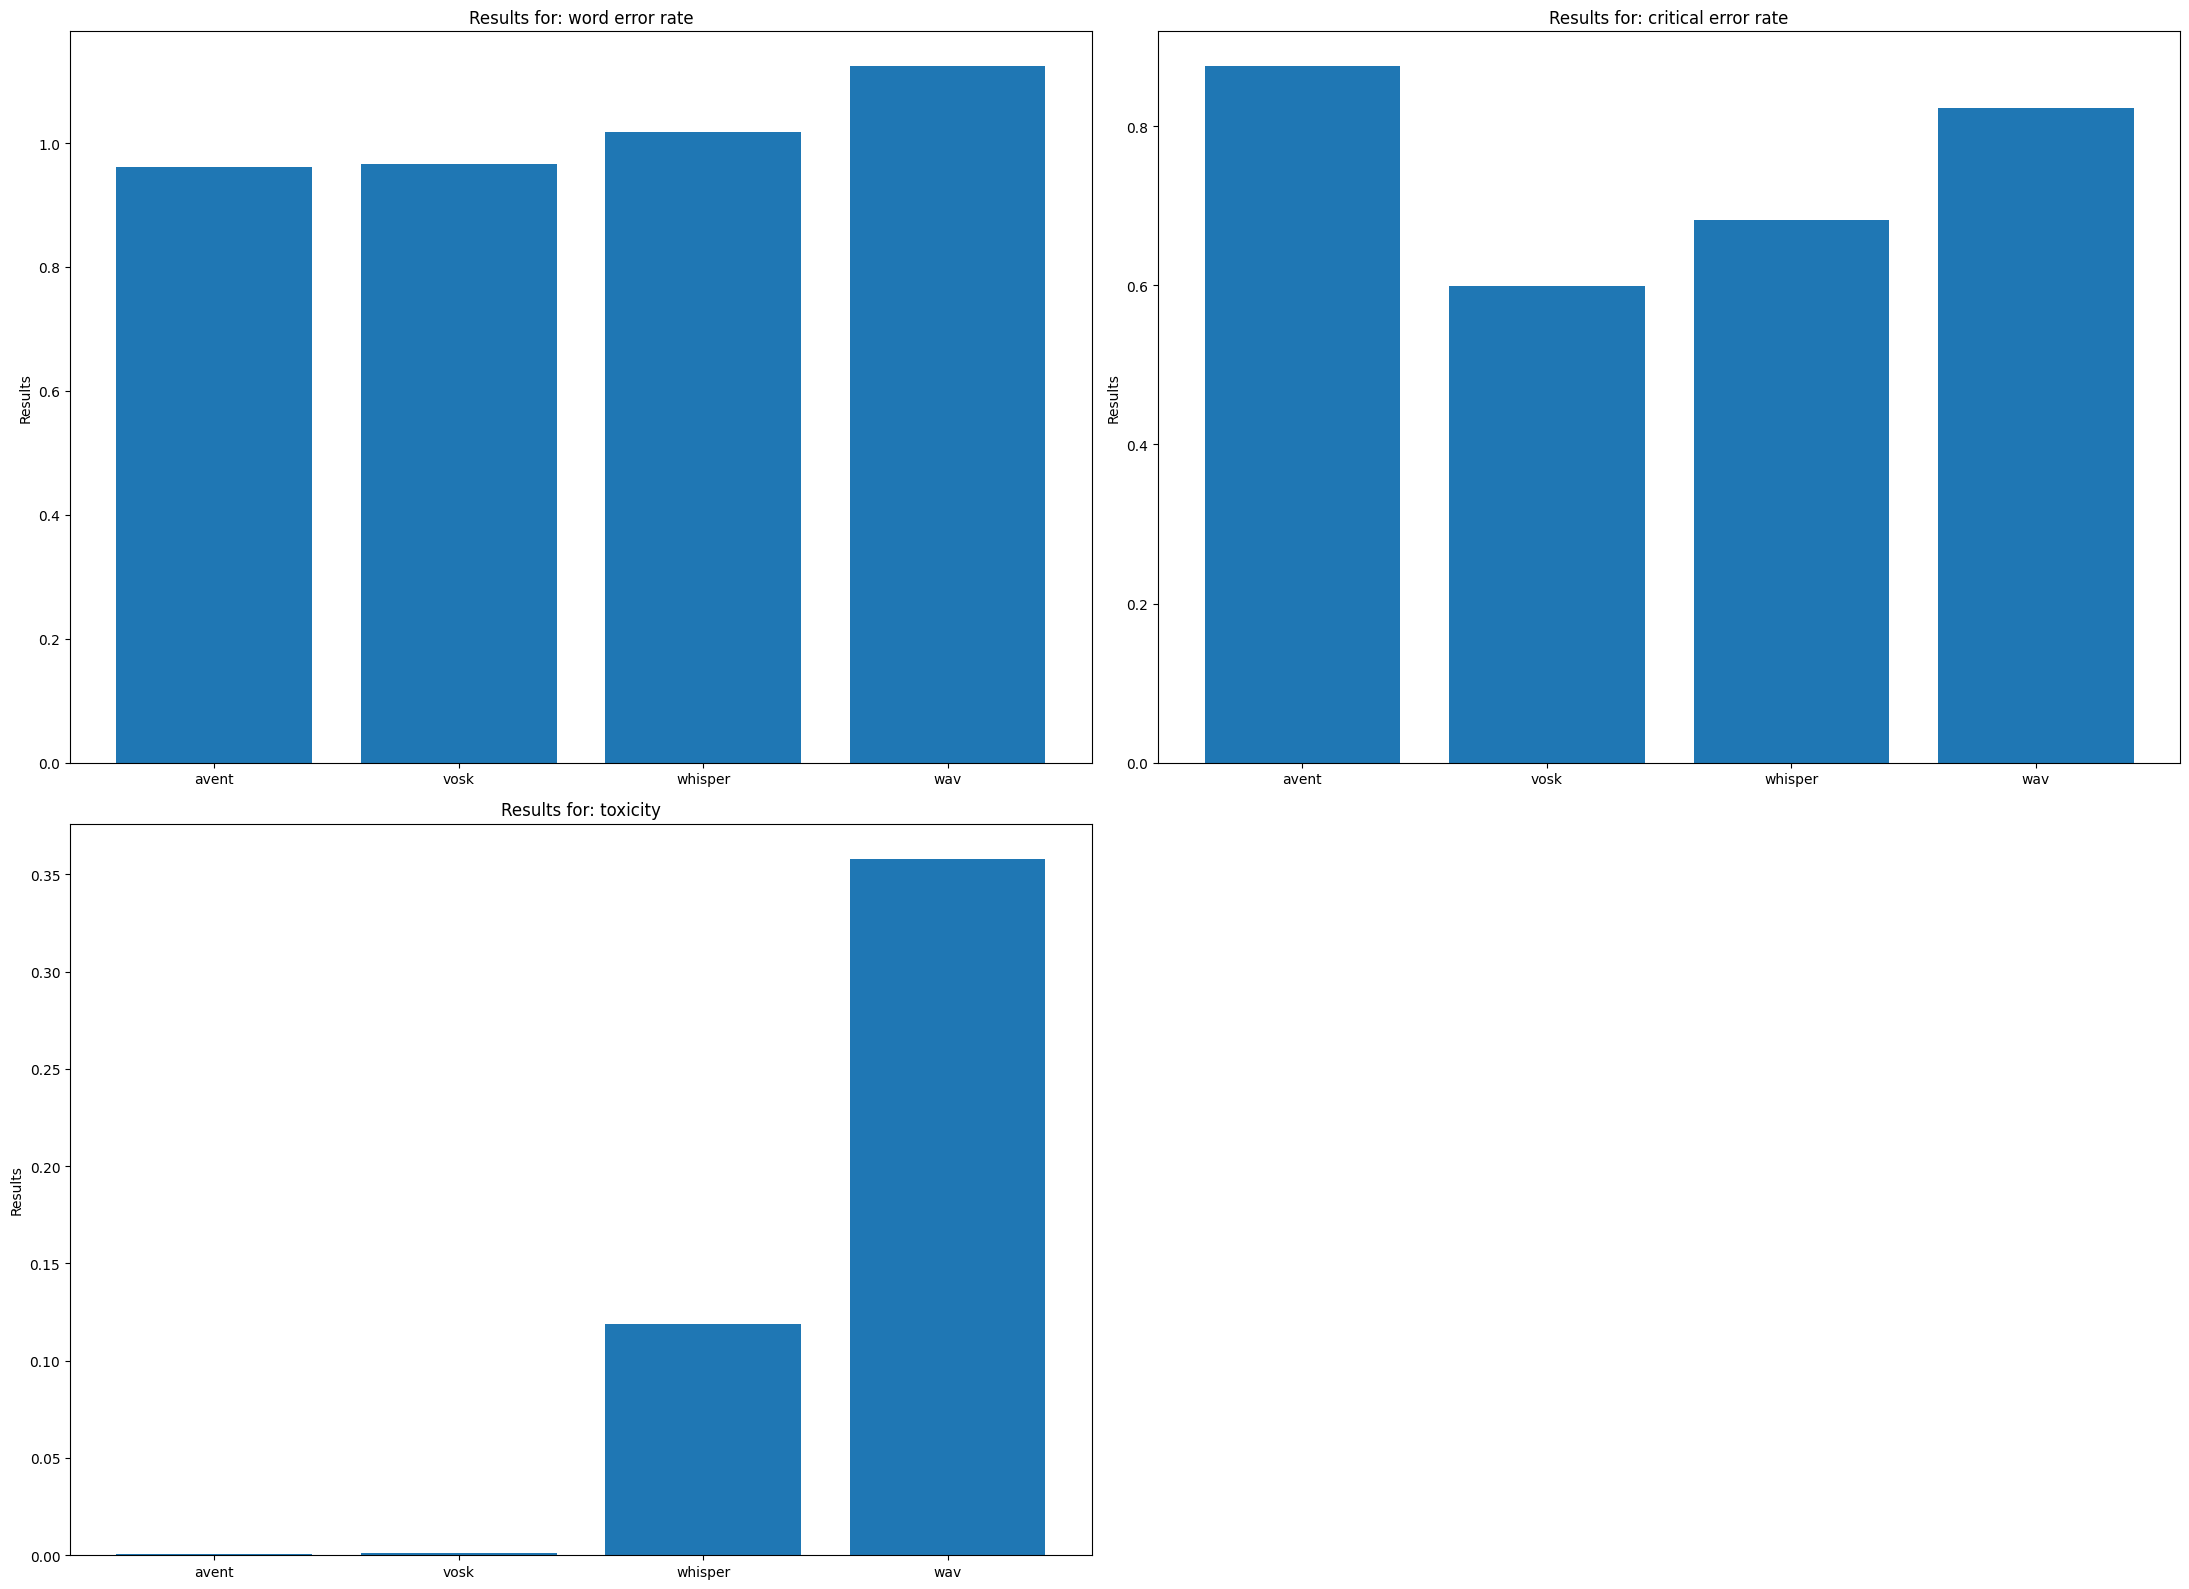

In [ ]:
import matplotlib.pyplot as plt

results = {
    'avent': [avent_wer, avent_cer, avent_toxicity],
    'vosk': [vosk_wer, vosk_cer, vosk_toxicity],
    'whisper': [whisper_wer, whisper_cer, whisper_toxicity],
    'wav': [wav_wer, wav_cer, wav_toxicity],
}

metrics = ['word error rate', 'critical error rate', 'toxicity']

num_plots = len(metrics)

# Calculate number of rows needed for 2 columns
n_cols = 2
n_rows = (num_plots + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols + 10, 3 * n_rows + 10))
axes = axes.flatten()

for i in range(num_plots):
  values = [results[k][i] for k in results.keys()]
  axes[i].bar(results.keys(), values)
  axes[i].set_title(f'Results for: {metrics[i]}')
  axes[i].set_ylabel('Results')

# Hide any unused subplots
for j in range(num_plots, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Best model is vosk